In [1]:
import sys
import os

# Add parent directory to path
sys.path.insert(0, os.path.abspath('..'))

from dataloader import load_data
df = load_data()
df.head()

,faction,winrate,overrep,fourzerostart,eventwins,playerpopulation
0,Aeldari,55,1.58,12,166,5
1,Genestealer Cults,54,1.54,12,57,2
2,Thousand Sons,53,1.27,10,58,3
3,Adepta Sororitas,52,1.33,11,71,3
4,Necrons,52,1.14,9,105,6


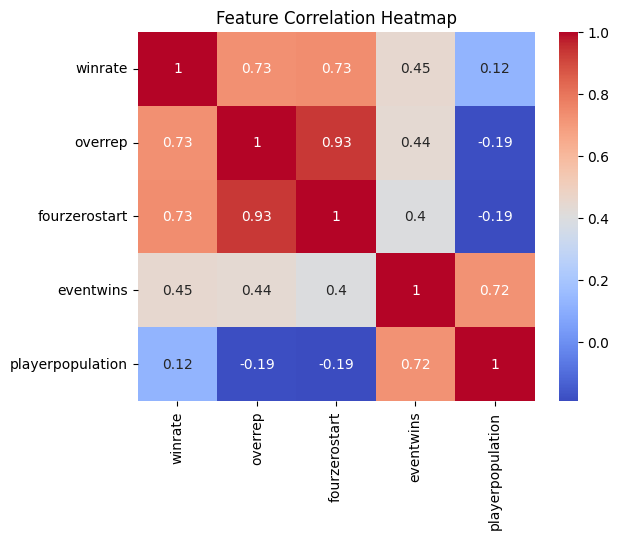

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

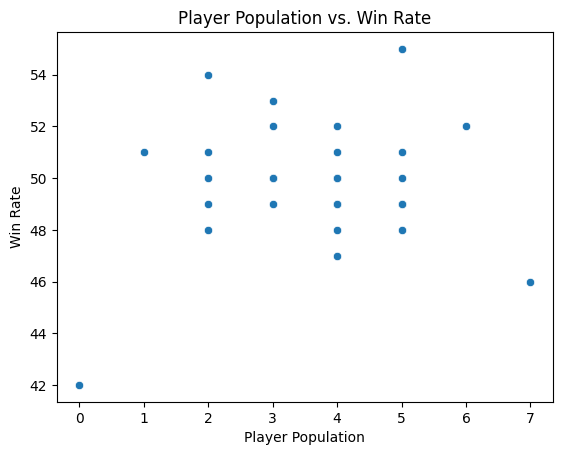

In [4]:
sns.scatterplot(data=df, x="playerpopulation", y="winrate")
plt.title("Player Population vs. Win Rate")
plt.xlabel("Player Population")
plt.ylabel("Win Rate")
plt.show()

In [5]:
df["playerpopulation"].corr(df["winrate"])

np.float64(0.12355353517043365)

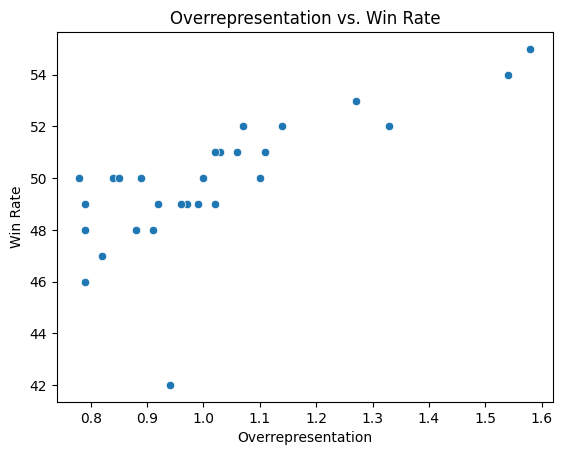

In [6]:
sns.scatterplot(data=df, x="overrep", y="winrate")
plt.title("Overrepresentation vs. Win Rate")
plt.xlabel("Overrepresentation")
plt.ylabel("Win Rate")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
sys.path.insert(0, os.path.abspath('..'))

from preprocessing import split_features_and_target, scale_features

X, y = split_features_and_target(df)
X_scaled, scaler = scale_features(X)

model = RandomForestRegressor(n_estimators=200, random_state=42)

scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
print(f"Cross-validated R² scores: {scores.mean()}")

In [ ]:
model.fit(X_scaled, y)

import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar')

plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[["winrate", "overrep", "eventwins", "fourzerostart"]])

df_scaled = pd.DataFrame(scaled, columns=["winrate", "overrep", "eventwins", "fourzerostart"])

df["meta_score"] = (0.4 * df_scaled["winrate"] + 0.3 * df_scaled["overrep"] + 0.2 * df_scaled["eventwins"] + 0.1 * df_scaled["fourzerostart"])

In [ ]:
import networkx as nx
from network import build_dominance_graph

G = build_dominance_graph(df)

pr = nx.pagerank(G, weight='weight')

pd.Series(pr).sort_values(ascending=False)